In [1]:
from pathlib import Path
import os

project_dir = Path("/content/drive/MyDrive/airborne-object-detection/dataset")

print(os.listdir(project_dir))

['test', 'validation', 'train']


In [2]:
from pathlib import Path
import os

project_dir = Path("/content/drive/MyDrive/airborne-object-detection")

data_dir = project_dir / "dataset"

train_dir = data_dir / "train"
val_dir = data_dir / "validation"
test_dir = data_dir / "test"

print("Train exists:", train_dir.exists(), train_dir)
print("Val exists:", val_dir.exists(), val_dir)
print("Test exists:", test_dir.exists(), test_dir)

print("Train classes:", os.listdir(train_dir))

Train exists: True /content/drive/MyDrive/airborne-object-detection/dataset/train
Val exists: True /content/drive/MyDrive/airborne-object-detection/dataset/validation
Test exists: True /content/drive/MyDrive/airborne-object-detection/dataset/test
Train classes: ['airplane', 'bird', 'helicopter', 'drone']


In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [4]:
img_size = 64
batch_size = 64

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [5]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=test_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=2
)

print("Classes:", train_dataset.classes)
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Classes: ['airplane', 'bird', 'drone', 'helicopter']
Train: 15240
Val: 4445
Test: 2165


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [7]:
model = SimpleCNN(num_classes=len(train_dataset.classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

SimpleCNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)


In [8]:
print("device:", device)
print("train size:", len(train_dataset))
print("batches:", len(train_loader))

images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

device: cuda
train size: 15240
batches: 239
torch.Size([64, 3, 64, 64]) torch.Size([64])


In [9]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        #Batch ilerleme
        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Batch {batch_idx}/{len(train_loader)}")

    # Epoch sonunda hesapla
    train_loss = total_loss / total
    train_acc = correct / total

    # validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total


    print(f"Epoch {epoch+1}/{epochs}: Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

Epoch 1/10 - Batch 0/239
Epoch 1/10 - Batch 10/239
Epoch 1/10 - Batch 20/239
Epoch 1/10 - Batch 30/239
Epoch 1/10 - Batch 40/239
Epoch 1/10 - Batch 50/239
Epoch 1/10 - Batch 60/239
Epoch 1/10 - Batch 70/239
Epoch 1/10 - Batch 80/239
Epoch 1/10 - Batch 90/239
Epoch 1/10 - Batch 100/239
Epoch 1/10 - Batch 110/239
Epoch 1/10 - Batch 120/239
Epoch 1/10 - Batch 130/239
Epoch 1/10 - Batch 140/239
Epoch 1/10 - Batch 150/239
Epoch 1/10 - Batch 160/239
Epoch 1/10 - Batch 170/239
Epoch 1/10 - Batch 180/239
Epoch 1/10 - Batch 190/239
Epoch 1/10 - Batch 200/239
Epoch 1/10 - Batch 210/239
Epoch 1/10 - Batch 220/239
Epoch 1/10 - Batch 230/239
Epoch 1/10: Loss=0.7193, Train Acc=0.6864, Val Acc=0.7654
Epoch 2/10 - Batch 0/239
Epoch 2/10 - Batch 10/239
Epoch 2/10 - Batch 20/239
Epoch 2/10 - Batch 30/239
Epoch 2/10 - Batch 40/239
Epoch 2/10 - Batch 50/239
Epoch 2/10 - Batch 60/239
Epoch 2/10 - Batch 70/239
Epoch 2/10 - Batch 80/239
Epoch 2/10 - Batch 90/239
Epoch 2/10 - Batch 100/239
Epoch 2/10 - Batch 

In [10]:
torch.save(model.state_dict(), "/content/drive/MyDrive/airborne-object-detection/cnn_real_only.pth")
print("Baseline CNN kaydedildi.")

Baseline CNN kaydedildi.


In [19]:
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [20]:
plt.savefig("accuracy_plot.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [21]:
plt.savefig("loss_plot.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

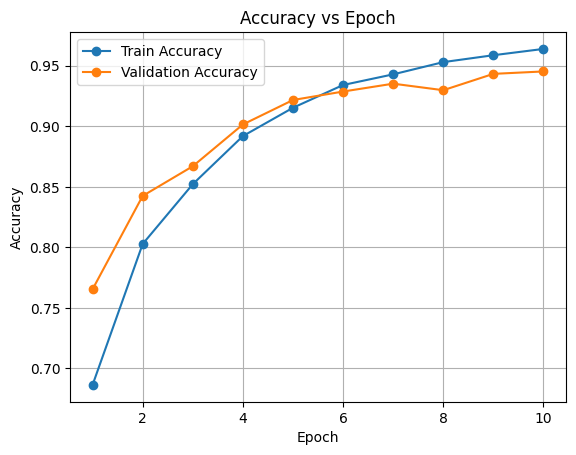

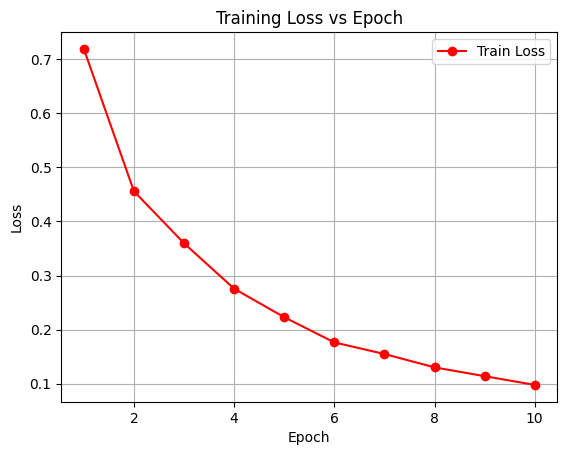

In [22]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))

train_loss = [0.7193, 0.4560, 0.3597, 0.2757, 0.2229, 0.1763, 0.1548, 0.1301, 0.1138, 0.0976]
train_acc  = [0.6864, 0.8028, 0.8522, 0.8919, 0.9153, 0.9341, 0.9429, 0.9530, 0.9587, 0.9639]
val_acc    = [0.7654, 0.8425, 0.8670, 0.9015, 0.9217, 0.9287, 0.9352, 0.9298, 0.9433, 0.9453]

# Accuracy grafiği
plt.figure()
plt.plot(epochs, train_acc, marker='o', label="Train Accuracy")
plt.plot(epochs, val_acc, marker='o', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid()
plt.show()

# Loss grafiği
plt.figure()
plt.plot(epochs, train_loss, marker='o', color='red', label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.legend()
plt.grid()
plt.show()

In [14]:
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

test_acc = test_correct / test_total
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9460


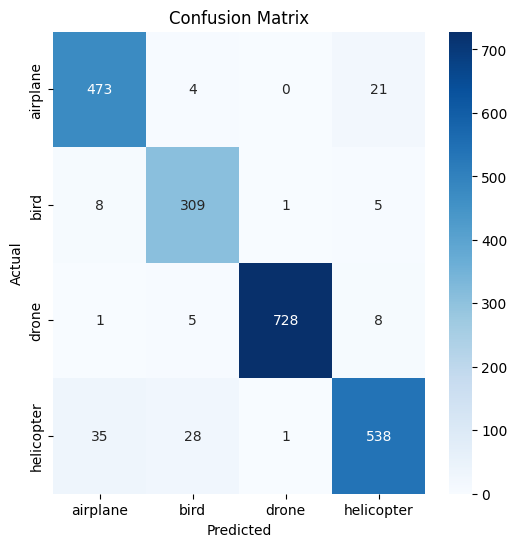

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()